# 05 - Robustness Tests

Evaluates the best model (selected in nb 04) on test subsets defined by session metadata: by session, by time-of-day band (derived from `window_start_time`), and by TX-RX distance (read from `_meta.json` via `load_session_metadata`).

> **Pilot limitation note.** All pilot sessions share a constant distance (2.0 m) and occur in the afternoon, so the distance split is a structural hook that gains meaning with the definitive dataset; each session contains a single class, so accuracy (fraction of correct windows) is the most informative per-session metric.

In [1]:
import sys
from pathlib import Path

_p = Path.cwd()
for ROOT in [_p, *_p.parents]:
    if (ROOT / "requirements.txt").exists():
        break
sys.path.insert(0, str(ROOT / "src"))

import json
import warnings

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.exceptions import UndefinedMetricWarning

from preprocessing import load_feature_table, split_features_metadata
from parsing import load_session_metadata
from evaluation import compute_metrics

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

SPLITS_DIR = ROOT / "data" / "splits"
MODELS_DIR = ROOT / "models"
META_DIR = ROOT / "data" / "pilot"
OUT_DIR = ROOT / "outputs" / "pilot" / "modeling"
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
report = json.loads((OUT_DIR / "metrics_report.json").read_text())
best_name = report["best_model"]
best_model = joblib.load(MODELS_DIR / f"{best_name}.pkl")
scaler = joblib.load(MODELS_DIR / "scaler.pkl")
print("evaluating robustness of best model:", best_name)

evaluating robustness of best model: svm


In [3]:
test = load_feature_table(SPLITS_DIR / "test.parquet")
X_test, y_test, meta_test = split_features_metadata(test)
pred = best_model.predict(scaler.transform(X_test))

eval_df = meta_test.copy()
eval_df["y_true"] = y_test.values
eval_df["y_pred"] = pred
eval_df["hour"] = pd.to_datetime(eval_df["window_start_time"]).dt.hour
eval_df["time_of_day"] = pd.cut(eval_df["hour"], bins=[0, 12, 18, 24], right=False,
                                 labels=["morning", "afternoon", "evening"])

session_meta = load_session_metadata(META_DIR)
eval_df = eval_df.join(session_meta[["tx_rx_los_distance_m"]], on="session_id")
eval_df[["session_id", "label", "time_of_day", "tx_rx_los_distance_m",
         "y_true", "y_pred"]].head()

,session_id,label,time_of_day,tx_rx_los_distance_m,y_true,y_pred
267,C,0,afternoon,2.0,0,0
421,D,1,afternoon,2.0,1,1
1153,F,0,afternoon,2.0,0,0
200,C,0,afternoon,2.0,0,0
216,C,0,afternoon,2.0,0,0


In [4]:
def grouped_metrics(df, by):
    """Compute presence metrics for each subgroup of df grouped by the given column."""
    out = []
    for key, g in df.groupby(by, observed=True):
        if len(g) == 0:
            continue
        out.append({by: key, "n": len(g), **compute_metrics(g["y_true"], g["y_pred"])})
    return pd.DataFrame(out)

  session_id   n  accuracy  f1_macro  false_alarm_rate
0          C  48  1.000000  1.000000               0.0
1          D  45  1.000000  1.000000               0.0
2          E  45  0.977778  0.494382               0.0
3          F  42  1.000000  1.000000               0.0


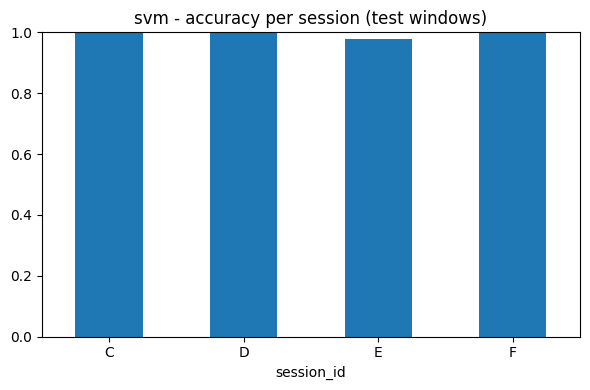

In [5]:
per_session = grouped_metrics(eval_df, "session_id")
per_session.to_csv(OUT_DIR / "robustness_per_session.csv", index=False)
print(per_session)
ax = per_session.set_index("session_id")["accuracy"].plot.bar(figsize=(6, 4), rot=0)
ax.set_title(f"{best_name} - accuracy per session (test windows)")
ax.set_ylim(0, 1)
ax.figure.tight_layout()
ax.figure.savefig(OUT_DIR / "robustness_per_session.png", dpi=150)
plt.show()

In [6]:
per_tod = grouped_metrics(eval_df, "time_of_day")
print(per_tod)

  time_of_day    n  accuracy  f1_macro  false_alarm_rate
0   afternoon  180  0.994444  0.994444               0.0


In [7]:
# Distance robustness: generic filter, activates when >1 distance is present.
distances = sorted(eval_df["tx_rx_los_distance_m"].dropna().unique())
print("distances present in test:", distances)
if len(distances) > 1:
    print(grouped_metrics(eval_df, "tx_rx_los_distance_m"))
else:
    print(f"Only one distance ({distances[0]} m) in the pilot - distance-based "
          "robustness becomes meaningful with the definitive dataset.")

distances present in test: [np.float64(2.0)]
Only one distance (2.0 m) in the pilot - distance-based robustness becomes meaningful with the definitive dataset.
